# Lab 01 — Search Foundations on an Airline Network

**Objective.** Compare BFS, DFS and UCS on one cleaned airline graph, verify every path, and distinguish route quality from search effort.

**Data.** `all_datasets/lab01-03_airports.csv` and `lab01-03_routes.csv`.

**Run.** From the course folder, run `cd all_experiments`, start Jupyter, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab01/metrics.csv` and `route_comparison.png`.

**Workflow**

1. Load and validate the graph.
2. Define the edge cost.
3. Run BFS, DFS and UCS on the three standard queries.
4. Verify every path independently.
5. Compare the objectives.
6. Save the evidence.


## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from utils import bfs, dfs, ucs, haversine_km, load_openflights, plot_route_paths, route_is_valid

ROOT = Path.cwd().parent                     # the course folder
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab01"
RESULTS.mkdir(parents=True, exist_ok=True)

## Question 1 — Load and validate the graph

Load the airport and route files, keep only airports with a valid IATA code and
coordinates, drop routes whose endpoints are unusable, and collapse duplicate routes. Report
how many rows survive each step and show the three standard queries.

In [2]:
airports, routes, coords, graph, stats = load_openflights(DATA / "lab01-03_airports.csv", DATA / "lab01-03_routes.csv")
queries = pd.read_csv("utils/search_queries.csv").head(3)

display(pd.Series(stats, name="count").to_frame())
display(queries)

,count
airport_rows,10668
valid_airports,6464
route_rows,67663
unique_valid_routes,37337
removed_route_rows,30326


,query_id,start,goal
0,Q1,KUL,KEF
1,Q2,SIN,EZE
2,Q3,NRT,CPT


**Result and interpretation.** Of 10,668 airport rows, 6,464 have a usable code and coordinates; of 67,663
route rows, 37,337 unique directed routes connect two usable airports. Every algorithm below
runs on this same graph, so their results can be compared.

## Question 2 — Define the edge cost

BFS and DFS count every route as one step. UCS needs a number: the great-circle
(Haversine) distance in kilometres between the two airports. Show the first five routes out
of KUL with their distances, and the straight-line distance from KUL to KEF.

In [3]:
sample = pd.DataFrame(graph["KUL"][:5], columns=["destination", "distance_km"])
display(sample.round(1))

direct_km = haversine_km(coords["KUL"]["latitude"], coords["KUL"]["longitude"],
                         coords["KEF"]["latitude"], coords["KEF"]["longitude"])
print(f"KUL has {len(graph['KUL'])} outgoing routes")
print(f"Great-circle distance KUL -> KEF: {direct_km:,.0f} km (no direct route exists)")

,destination,distance_km
0,ADL,5681.8
1,AKL,8703.4
2,ALA,5130.5
3,AMD,3861.2
4,AMS,10236.7


KUL has 112 outgoing routes
Great-circle distance KUL -> KEF: 11,316 km (no direct route exists)


**Result and interpretation.** Each edge carries the distance between its endpoints, computed once when the
graph is built. Counting steps (BFS/DFS) and summing kilometres (UCS) are two different
questions asked of the same graph.

## Question 3 — Run BFS, DFS and UCS on the three standard queries

Record path, hops, distance, expanded nodes, maximum frontier and runtime for every
algorithm and query, and save the table as `metrics.csv`.

In [4]:
rows = []
for query in queries.itertuples():
    for name, algorithm in [("BFS", bfs), ("DFS", dfs), ("UCS", ucs)]:
        result = algorithm(graph, query.start, query.goal)
        rows.append({"query_id": query.query_id, "start": query.start, "goal": query.goal,
                     "algorithm": name, **result.as_dict(), "path": " -> ".join(result.path)})

metrics = pd.DataFrame(rows).drop(columns="found")
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics.drop(columns=["start", "goal", "path"]).round(2))

,query_id,algorithm,hops,path_cost_km,expanded,max_frontier,runtime_ms
0,Q1,BFS,2,12274.32,284,1679,4.88
1,Q1,DFS,23,41767.82,2112,859,4.06
2,Q1,UCS,4,11461.35,1851,616,6.84
3,Q2,BFS,2,21976.11,233,1629,3.02
4,Q2,DFS,39,65213.84,904,858,3.03
5,Q2,UCS,3,17817.36,3002,620,8.28
6,Q3,BFS,2,19005.89,173,1727,3.08
7,Q3,DFS,64,91541.43,1414,785,3.27
8,Q3,UCS,3,14813.32,3042,1018,8.46


**Result and interpretation.** BFS always returns the fewest hops (two legs on every query), UCS always
returns the shortest distance, and DFS returns a long, winding route because it follows the
first neighbour deeply. Expanded-node counts are the stable measure of effort; runtimes vary
from machine to machine.

## Question 4 — Verify every path independently

A reported path is only evidence if it can be checked. Confirm that every consecutive
pair of airports in every path is a real route, and recompute each path cost by summing the
edge distances.

In [5]:
edge_km = {airport: dict(neighbours) for airport, neighbours in graph.items()}

for row in metrics.itertuples():
    path = row.path.split(" -> ")
    assert route_is_valid(path, graph), f"{row.algorithm} {row.query_id}: a leg is not a real route"
    recomputed = sum(edge_km[a][b] for a, b in zip(path, path[1:]))
    assert np.isclose(recomputed, row.path_cost_km), f"{row.algorithm} {row.query_id}: cost mismatch"

print(f"Verified {len(metrics)} paths: every leg exists and every cost matches its edge sum")

Verified 9 paths: every leg exists and every cost matches its edge sum


**Result and interpretation.** All nine paths use real routes and their costs equal the sum of their edge
distances, so the metrics table can be trusted.

## Question 5 — Compare the objectives

Show hops and distance side by side for the three algorithms. Then run DFS again with every
neighbour list reversed to show that its answer depends on neighbour order.

In [6]:
display(metrics.pivot(index="query_id", columns="algorithm", values=["hops", "path_cost_km"]).round(0))

reversed_graph = {airport: neighbours[::-1] for airport, neighbours in graph.items()}
for query in queries.itertuples():
    original = dfs(graph, query.start, query.goal).hops
    reordered = dfs(reversed_graph, query.start, query.goal).hops
    print(f"{query.query_id} DFS: {original} hops with the original order, {reordered} with the reversed order")

hops            path_cost_km                  
algorithm  BFS   DFS  UCS          BFS      DFS      UCS
query_id                                                
Q1         2.0  23.0  4.0      12274.0  41768.0  11461.0
Q2         2.0  39.0  3.0      21976.0  65214.0  17817.0
Q3         2.0  64.0  3.0      19006.0  91541.0  14813.0

Q1 DFS: 23 hops with the original order, 8 with the reversed order
Q2 DFS: 39 hops with the original order, 41 with the reversed order
Q3 DFS: 64 hops with the original order, 39 with the reversed order


**Result and interpretation.** BFS minimises the number of legs, so a two-leg route through a distant hub
(KUL → AMS → KEF) wins even though UCS finds a four-leg route that is over 800 km shorter.
Fewest legs and fewest kilometres are different objectives. DFS changes its answer as soon
as the neighbour order changes, because it commits to the first branch it sees; it
guarantees neither objective.

## Question 6 — Save the evidence

Plot the three KUL → KEF routes and save the figure next to `metrics.csv`.

Saved: ['metrics.csv', 'route_comparison.png']


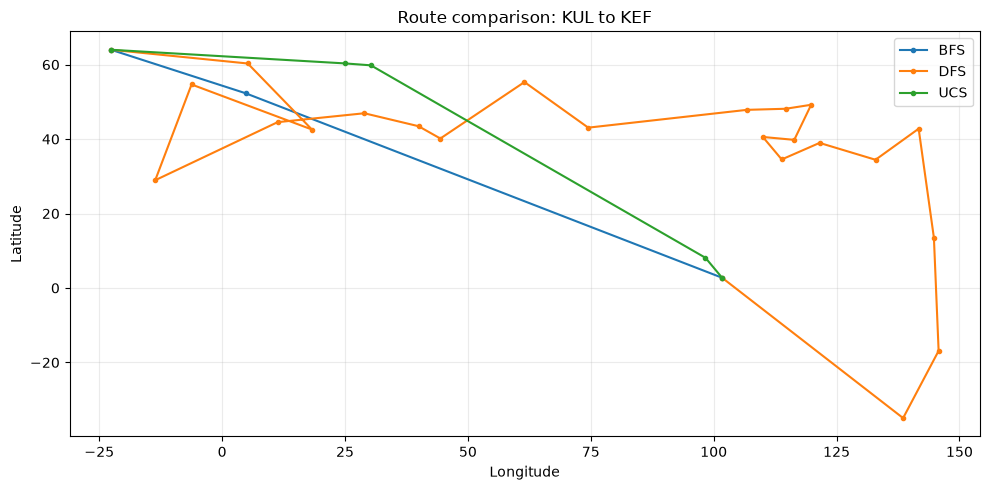

In [7]:
q1 = metrics[metrics.query_id == "Q1"]
paths = {row.algorithm: row.path.split(" -> ") for row in q1.itertuples()}
figure, _ = plot_route_paths(paths, coords, title="Route comparison: KUL to KEF")
figure.savefig(RESULTS / "route_comparison.png", dpi=160, bbox_inches="tight")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

**Result and interpretation.** The figure is a longitude/latitude sketch, not a map projection, but it makes
the difference visible: BFS jumps through one hub, UCS follows the geographically short
chain, and DFS wanders. Evidence: `results/lab01/metrics.csv`,
`results/lab01/route_comparison.png` and this executed notebook.

## Submission checklist

- Restart the kernel and run all cells without errors.
- Submit this executed notebook and the generated `results/lab01/` folder.
- Add a short conclusion: Identify which method minimises hops, which minimises distance, why DFS changes with neighbour order, and which effort measure is comparable across computers.
